# Crime and Event ML Analysis

This notebook explores the relationship between crime and events data, and trains machine learning models to predict crime patterns based on events and other features.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_regression

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 1. Load and Explore Data


In [2]:
# Load datasets
crime_path = '../datasets/Crime/crime_dataset.csv'
events_path = '../datasets/Events/Chicago_Park_District_-_Event_Permits_With_Neighborhoods.csv'

print("Loading crime data...")
# Read first few rows to check structure
crime_df_sample = pd.read_csv(crime_path, nrows=5)
print("Sample of crime data structure:")
print(crime_df_sample)
print("\nCrime columns:", crime_df_sample.columns.tolist())

# Now load full dataset (this may take a while for large files)
print("\nLoading full crime dataset (this may take a moment for large files)...")
crime_df = pd.read_csv(crime_path, low_memory=True)
print(f"Crime data shape: {crime_df.shape}")

print("\nLoading events data...")
events_df = pd.read_csv(events_path)
print(f"Events data shape: {events_df.shape}")

# Display basic info
print("\n=== Crime Data Info ===")
print(crime_df.head())
print("\nCrime columns:", crime_df.columns.tolist())
print("\nCrime data types:")
print(crime_df.dtypes)
print("\nMissing values:")
print(crime_df.isnull().sum().sum(), "total missing values")

print("\n=== Events Data Info ===")
print(events_df.head())
print("\nEvents columns:", events_df.columns.tolist())
print("\nMissing values:")
print(events_df.isnull().sum().sum(), "total missing values")


Loading crime data...
Sample of crime data structure:
                  date                   block   primary type  \
0  2023-06-19 22:30:00   080xx s champlain ave          theft   
1  2014-11-05 12:50:00     034xx n western ave          theft   
2  2024-04-21 21:00:00     035xx w flournoy st        battery   
3  2022-03-13 13:30:00     019xx w superior st  other offense   
4  2025-03-07 03:08:00  009xx n monticello ave       burglary   

               description location description  arrest  domestic  beat  \
0           $500 and under            apartment   False     False   631   
1             retail theft   grocery food store    True     False  1921   
2  domestic battery simple            apartment   False      True  1133   
3         telephone threat            apartment   False      True  1221   
4           forcible entry            residence    True     False  1112   

   district  community area fbi code  x coordinate  y coordinate  year  \
0       6.0            44.0   

In [3]:
# Clean and prepare crime data
print("Preparing crime data...")
# The date column is already in datetime format or can be parsed directly
crime_df['date'] = pd.to_datetime(crime_df['date'], errors='coerce')
crime_df = crime_df.dropna(subset=['date', 'neighborhood'])

# Filter to reasonable date range
crime_df = crime_df[crime_df['date'] >= '2014-01-01']
crime_df = crime_df[crime_df['date'] < '2025-01-01']

print(f"Crime records after cleaning: {len(crime_df):,}")
print(f"Date range: {crime_df['date'].min()} to {crime_df['date'].max()}")
print(f"Unique neighborhoods: {crime_df['neighborhood'].nunique()}")
print(f"Unique crime types: {crime_df['primary type'].nunique()}")
print("\nTop 10 crime types:")
print(crime_df['primary type'].value_counts().head(10))


Preparing crime data...
Crime records after cleaning: 2,698,897
Date range: 2014-01-01 00:00:00 to 2024-12-31 23:58:00
Unique neighborhoods: 98
Unique crime types: 33

Top 10 crime types:
primary type
theft                  606666
battery                500224
criminal damage        299932
assault                213790
deceptive practice     177604
other offense          171701
motor vehicle theft    151035
narcotics              127244
burglary               112759
robbery                103683
Name: count, dtype: int64


In [4]:
# Clean and prepare events data
print("Preparing events data...")
events_df['Reservation Start Date'] = pd.to_datetime(events_df['Reservation Start Date'], errors='coerce')
events_df['Reservation End Date'] = pd.to_datetime(events_df['Reservation End Date'], errors='coerce')

# Filter to approved/issued events only
events_df = events_df[events_df['Permit Status'].isin(['Approved', 'Issued', 'Completed'])]
events_df = events_df.dropna(subset=['Reservation Start Date', 'Neighborhood'])

print(f"Events after cleaning: {len(events_df):,}")
print(f"Date range: {events_df['Reservation Start Date'].min()} to {events_df['Reservation Start Date'].max()}")
print(f"Unique neighborhoods: {events_df['Neighborhood'].nunique()}")
print(f"Unique event types: {events_df['Event Type'].nunique()}")
print("\nTop 10 event types:")
print(events_df['Event Type'].value_counts().head(10))


Preparing events data...
Events after cleaning: 116,853
Date range: 2012-01-07 00:00:00 to 2025-12-31 00:00:00
Unique neighborhoods: 186
Unique event types: 62

Top 10 event types:
Event Type
Permit - Athletic Training                           31099
Administrative Reservation - Internal Hold PARKS     17571
Permit - Athletic T Cluster 3                         6537
Permit - Festival/Performance/12,001+ Event           5513
Permit - Media: Non-Commercial Photography Online     5008
Permit - Event 6/10,000+                              4542
Permit - Media: Non-Commercial Photography            3951
Administrative Reservation - Park Legacy Items        3243
Permit - Picnic Level 1                               2987
Permit - Event 1 Cluster 3                            2899
Name: count, dtype: int64


## 2. Feature Engineering


In [5]:
# Create daily aggregation of crime by neighborhood
print("Creating daily crime aggregations...")
# Extract date part (without time) for daily aggregation
crime_df['date_only'] = crime_df['date'].dt.date
crime_daily = crime_df.groupby(['date_only', 'neighborhood']).agg({
    'date': 'count',  # Total crime count (using date column to count)
    'primary type': lambda x: x.value_counts().to_dict()  # Crime type distribution
}).reset_index()
crime_daily.columns = ['date', 'neighborhood', 'crime_count', 'crime_types']

# Create daily event aggregations
print("Creating daily event aggregations...")
events_df['date'] = events_df['Reservation Start Date'].dt.date
events_daily = events_df.groupby(['date', 'Neighborhood']).agg({
    'Park/Facility Name': 'count',  # Event count
    'Event Type': lambda x: list(x)  # Event types
}).reset_index()
events_daily.columns = ['date', 'neighborhood', 'event_count', 'event_types']

print(f"Daily crime records: {len(crime_daily):,}")
print(f"Daily event records: {len(events_daily):,}")


Creating daily crime aggregations...
Creating daily event aggregations...
Daily crime records: 351,920
Daily event records: 61,175


In [7]:
# Create comprehensive feature set
print("Creating feature set...")

# Get all unique neighborhoods from both datasets
all_neighborhoods = set(crime_df['neighborhood'].unique()) | set(events_df['Neighborhood'].unique())
all_neighborhoods = sorted([n for n in all_neighborhoods if pd.notna(n)])

# Get date range - use datetime columns for comparison
# Convert date objects to datetime for proper comparison
crime_min_date = pd.to_datetime(crime_df['date'].min()).date()
crime_max_date = pd.to_datetime(crime_df['date'].max()).date()
events_min_date = events_df['Reservation Start Date'].min().date()
events_max_date = events_df['Reservation Start Date'].max().date()

min_date = min(crime_min_date, events_min_date)
max_date = max(crime_max_date, events_max_date)

# Create date range
all_dates = pd.date_range(start=min_date, end=max_date, freq='D')

print(f"Neighborhoods: {len(all_neighborhoods)}")
print(f"Date range: {min_date} to {max_date} ({len(all_dates)} days)")

# Create complete date-neighborhood grid
date_neighborhood_grid = []
for date in all_dates:
    for neighborhood in all_neighborhoods:
        date_neighborhood_grid.append({
            'date': date.date(),
            'neighborhood': neighborhood
        })

features_df = pd.DataFrame(date_neighborhood_grid)
print(f"Total date-neighborhood combinations: {len(features_df):,}")


Creating feature set...
Neighborhoods: 284
Date range: 2012-01-07 to 2025-12-31 (5108 days)
Total date-neighborhood combinations: 1,450,672


In [8]:
# Merge crime and event data
features_df = features_df.merge(
    crime_daily[['date', 'neighborhood', 'crime_count']],
    on=['date', 'neighborhood'],
    how='left'
)
features_df['crime_count'] = features_df['crime_count'].fillna(0).astype(int)

features_df = features_df.merge(
    events_daily[['date', 'neighborhood', 'event_count']],
    on=['date', 'neighborhood'],
    how='left'
)
features_df['event_count'] = features_df['event_count'].fillna(0).astype(int)

# Add temporal features
features_df['date_dt'] = pd.to_datetime(features_df['date'])
features_df['year'] = features_df['date_dt'].dt.year
features_df['month'] = features_df['date_dt'].dt.month
features_df['day_of_week'] = features_df['date_dt'].dt.dayofweek  # 0=Monday, 6=Sunday
features_df['day_of_month'] = features_df['date_dt'].dt.day
features_df['is_weekend'] = (features_df['day_of_week'] >= 5).astype(int)
features_df['is_month_start'] = (features_df['day_of_month'] <= 3).astype(int)
features_df['is_month_end'] = (features_df['day_of_month'] >= 28).astype(int)

# Add lag features for events (events in previous days)
print("Adding lag features...")
features_df = features_df.sort_values(['neighborhood', 'date'])
for lag in [1, 2, 3, 7]:
    features_df[f'event_count_lag_{lag}'] = features_df.groupby('neighborhood')['event_count'].shift(lag).fillna(0)

# Add rolling averages
for window in [7, 14, 30]:
    features_df[f'crime_count_rolling_{window}'] = features_df.groupby('neighborhood')['crime_count'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    features_df[f'event_count_rolling_{window}'] = features_df.groupby('neighborhood')['event_count'].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )

print(f"Feature set shape: {features_df.shape}")
print(f"Features: {features_df.columns.tolist()}")


Adding lag features...
Feature set shape: (1450672, 22)
Features: ['date', 'neighborhood', 'crime_count', 'event_count', 'date_dt', 'year', 'month', 'day_of_week', 'day_of_month', 'is_weekend', 'is_month_start', 'is_month_end', 'event_count_lag_1', 'event_count_lag_2', 'event_count_lag_3', 'event_count_lag_7', 'crime_count_rolling_7', 'event_count_rolling_7', 'crime_count_rolling_14', 'event_count_rolling_14', 'crime_count_rolling_30', 'event_count_rolling_30']


In [9]:
# Encode neighborhood as categorical
le_neighborhood = LabelEncoder()
features_df['neighborhood_encoded'] = le_neighborhood.fit_transform(features_df['neighborhood'])

# Select features for modeling
feature_cols = [
    'year', 'month', 'day_of_week', 'day_of_month', 'is_weekend', 
    'is_month_start', 'is_month_end',
    'event_count', 'event_count_lag_1', 'event_count_lag_2', 'event_count_lag_3', 'event_count_lag_7',
    'crime_count_rolling_7', 'crime_count_rolling_14', 'crime_count_rolling_30',
    'event_count_rolling_7', 'event_count_rolling_14', 'event_count_rolling_30',
    'neighborhood_encoded'
]

target_col = 'crime_count'

# Remove rows with NaN (shouldn't be many after fillna)
model_df = features_df[feature_cols + [target_col, 'date_dt']].dropna()

print(f"Model dataset shape: {model_df.shape}")
print(f"\nTarget distribution:")
print(model_df[target_col].describe())
zero_crime_pct = (model_df[target_col] == 0).sum() / len(model_df) * 100
print(f"\nZero crime days: {(model_df[target_col] == 0).sum():,} ({zero_crime_pct:.1f}%)")


Model dataset shape: (1450672, 21)

Target distribution:
count    1.450672e+06
mean     1.860446e+00
std      5.039180e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      1.820000e+02
Name: crime_count, dtype: float64

Zero crime days: 1,098,752 (75.7%)


## 3. Exploratory Data Analysis


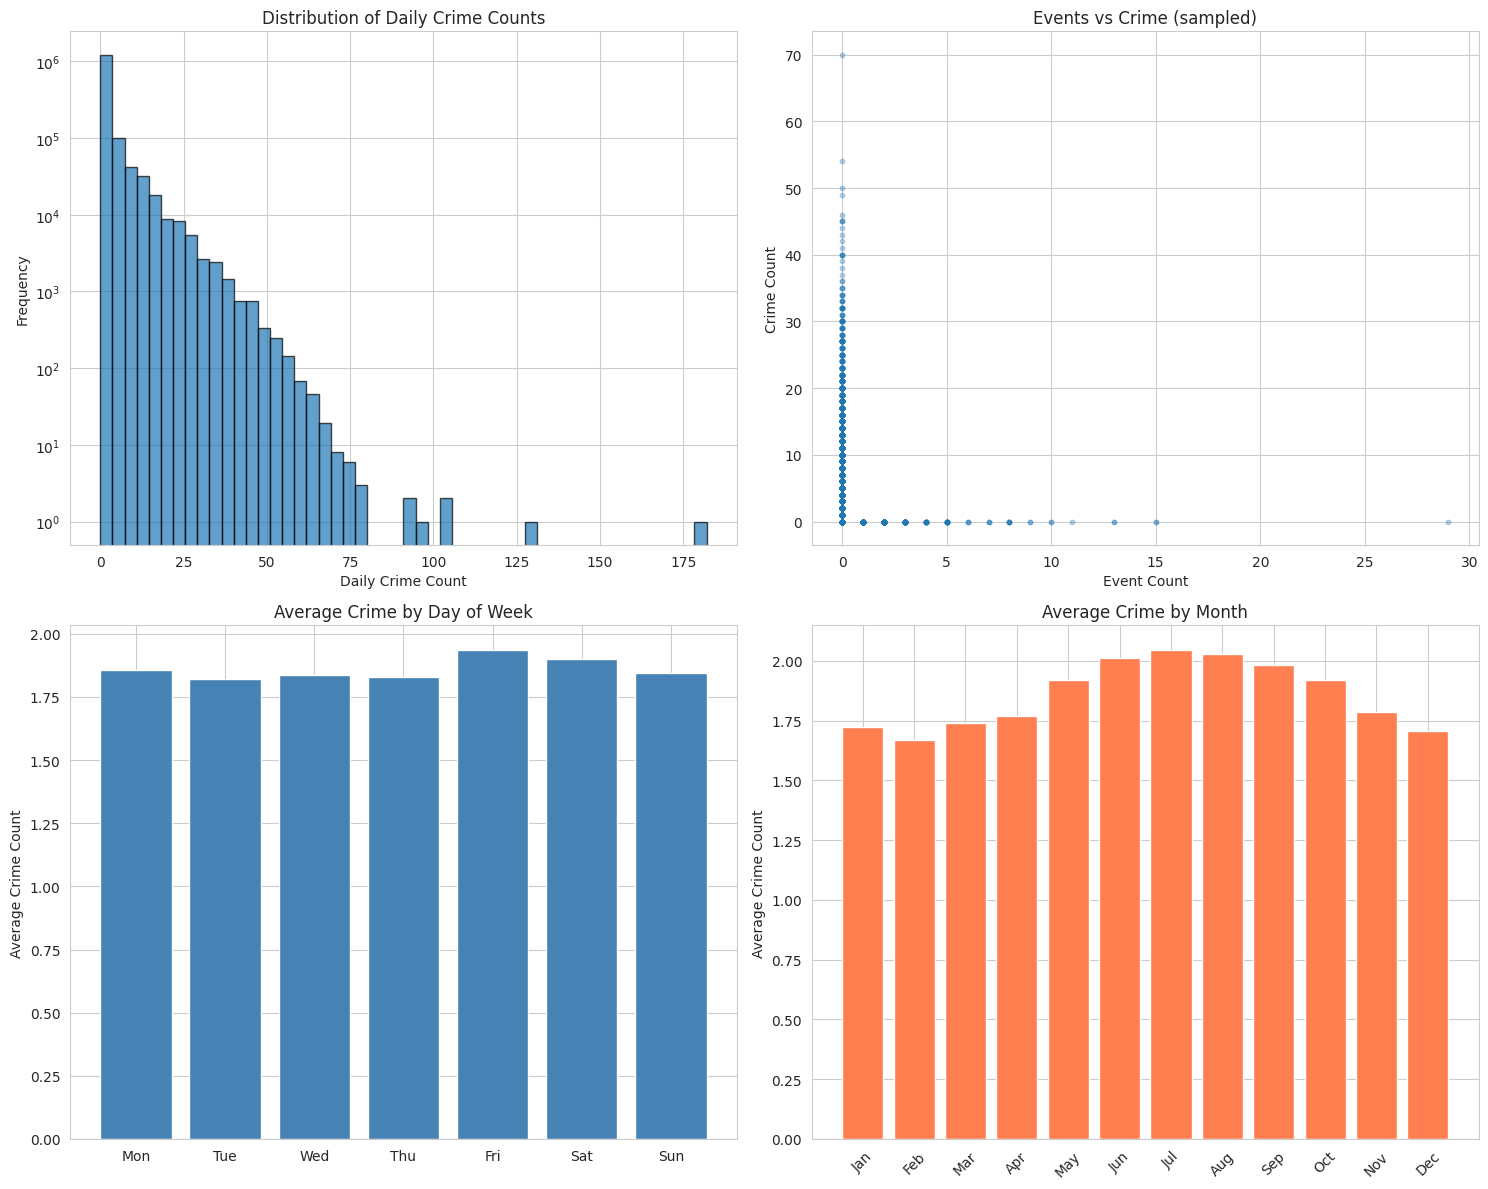


=== Correlation with Crime Count ===
crime_count               1.000000
crime_count_rolling_7     0.958033
crime_count_rolling_14    0.953185
crime_count_rolling_30    0.949386
neighborhood_encoded      0.414825
year                      0.033543
month                     0.008312
is_month_start            0.007521
day_of_week               0.003135
is_weekend                0.001420
is_month_end              0.000126
day_of_month             -0.003820
event_count_lag_7        -0.049442
event_count_lag_3        -0.049447
event_count_lag_2        -0.049448
event_count_lag_1        -0.049449
event_count              -0.049451
event_count_rolling_7    -0.056637
event_count_rolling_14   -0.058229
event_count_rolling_30   -0.060782
Name: crime_count, dtype: float64


In [23]:
# Visualize relationships
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Crime count distribution
axes[0, 0].hist(model_df[target_col], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Daily Crime Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Daily Crime Counts')
axes[0, 0].set_yscale('log')

# 2. Event count vs Crime count
sample_df = model_df.sample(min(10000, len(model_df)), random_state=42)
axes[0, 1].scatter(sample_df['event_count'], sample_df['crime_count'], alpha=0.3, s=10)
axes[0, 1].set_xlabel('Event Count')
axes[0, 1].set_ylabel('Crime Count')
axes[0, 1].set_title('Events vs Crime (sampled)')

# 3. Crime by day of week
dow_crime = model_df.groupby('day_of_week')[target_col].mean()
axes[1, 0].bar(range(7), dow_crime.values, color='steelblue')
axes[1, 0].set_xticks(range(7))
axes[1, 0].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1, 0].set_ylabel('Average Crime Count')
axes[1, 0].set_title('Average Crime by Day of Week')

# 4. Crime by month
month_crime = model_df.groupby('month')[target_col].mean()
axes[1, 1].bar(range(1, 13), month_crime.values, color='coral')
axes[1, 1].set_xticks(range(1, 13))
axes[1, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                            'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
axes[1, 1].set_ylabel('Average Crime Count')
axes[1, 1].set_title('Average Crime by Month')

plt.tight_layout()
plt.savefig('../UrbanPulse-report/content/figures/crime_event_ml_eda.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation analysis
print("\n=== Correlation with Crime Count ===")
correlations = model_df[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
print(correlations)


## 4. Machine Learning Models

### 4.1 Regression: Predicting Daily Crime Count


In [11]:
# Prepare data for regression
X = model_df[feature_cols]
y = model_df[target_col]

# Split data (use temporal split to avoid data leakage)
split_date = model_df['date_dt'].quantile(0.8)
train_mask = features_df['date_dt'] < split_date
test_mask = features_df['date_dt'] >= split_date

train_df = model_df[train_mask]
test_df = model_df[test_mask]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
X_test = test_df[feature_cols]
y_test = test_df[target_col]

print(f"Training set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")
print(f"\nTrain date range: {train_df['date_dt'].min()} to {train_df['date_dt'].max()}")
print(f"Test date range: {test_df['date_dt'].min()} to {test_df['date_dt'].max()}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Training set: 1,160,424 samples
Test set: 290,248 samples

Train date range: 2012-01-07 00:00:00 to 2023-03-15 00:00:00
Test date range: 2023-03-16 00:00:00 to 2025-12-31 00:00:00


In [12]:
# Train multiple regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

print("Training regression models...\n")
for name, model in models.items():
    print(f"Training {name}...")
    
    # Use scaled features for linear models, original for tree-based
    if name in ['Linear Regression', 'Ridge Regression', 'Lasso Regression']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'predictions': y_pred
    }
    
    print(f"  RMSE: {rmse:.2f}, MAE: {mae:.2f}, R²: {r2:.4f}\n")

# Display results
results_df = pd.DataFrame(results).T[['RMSE', 'MAE', 'R2']]
print("\n=== Model Comparison ===")
print(results_df.sort_values('RMSE'))


Training regression models...

Training Linear Regression...
  RMSE: 1.33, MAE: 0.46, R²: 0.9120

Training Ridge Regression...
  RMSE: 1.33, MAE: 0.46, R²: 0.9120

Training Lasso Regression...
  RMSE: 1.59, MAE: 0.80, R²: 0.8752

Training Random Forest...
  RMSE: 1.37, MAE: 0.45, R²: 0.9068

Training Gradient Boosting...
  RMSE: 1.33, MAE: 0.45, R²: 0.9122


=== Model Comparison ===
                       RMSE       MAE        R2
Gradient Boosting  1.330272   0.44906  0.912151
Linear Regression  1.331212   0.46385  0.912027
Ridge Regression   1.331213  0.463851  0.912027
Random Forest       1.37045  0.454628  0.906764
Lasso Regression   1.585461   0.79649  0.875214


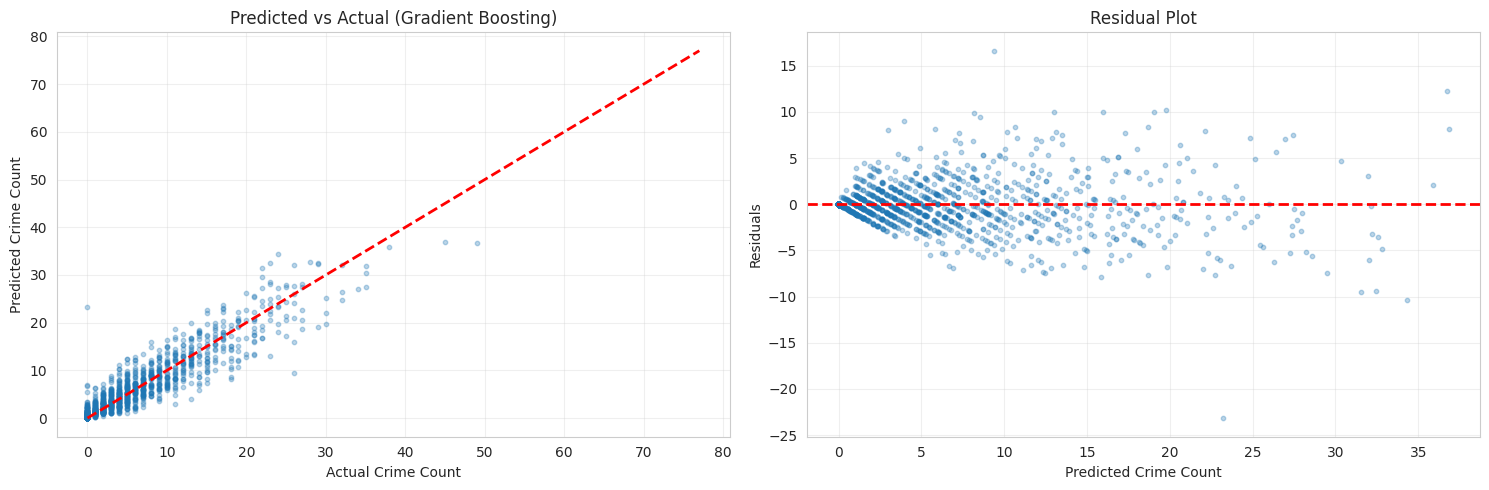


Best Model: Gradient Boosting
RMSE: 1.33
MAE: 0.45
R²: 0.9122


In [24]:
# Visualize predictions for best model
best_model_name = results_df.sort_values('RMSE').index[0]
best_predictions = results[best_model_name]['predictions']

# Convert to numpy arrays for consistent indexing
y_test_array = y_test.values if hasattr(y_test, 'values') else np.array(y_test)
best_predictions_array = np.array(best_predictions)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Scatter plot: predicted vs actual
sample_size = min(5000, len(y_test_array))
sample_idx = np.random.choice(len(y_test_array), sample_size, replace=False)
axes[0].scatter(y_test_array[sample_idx], best_predictions_array[sample_idx], alpha=0.3, s=10)
axes[0].plot([y_test_array.min(), y_test_array.max()], 
             [y_test_array.min(), y_test_array.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Crime Count')
axes[0].set_ylabel('Predicted Crime Count')
axes[0].set_title(f'Predicted vs Actual ({best_model_name})')
axes[0].grid(True, alpha=0.3)

# Residual plot
residuals = y_test_array - best_predictions_array
axes[1].scatter(best_predictions_array[sample_idx], residuals[sample_idx], alpha=0.3, s=10)
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Crime Count')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../UrbanPulse-report/content/figures/crime_prediction_plots.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest Model: {best_model_name}")
print(f"RMSE: {results[best_model_name]['RMSE']:.2f}")
print(f"MAE: {results[best_model_name]['MAE']:.2f}")
print(f"R²: {results[best_model_name]['R2']:.4f}")



=== Feature Importance (Random Forest) ===
                   feature  importance
12   crime_count_rolling_7    0.924354
14  crime_count_rolling_30    0.017113
13  crime_count_rolling_14    0.014751
3             day_of_month    0.012408
18    neighborhood_encoded    0.008370
1                    month    0.008242
0                     year    0.007260
2              day_of_week    0.005818
4               is_weekend    0.000729
6             is_month_end    0.000592
5           is_month_start    0.000362
10       event_count_lag_3    0.000000
9        event_count_lag_2    0.000000
8        event_count_lag_1    0.000000
7              event_count    0.000000


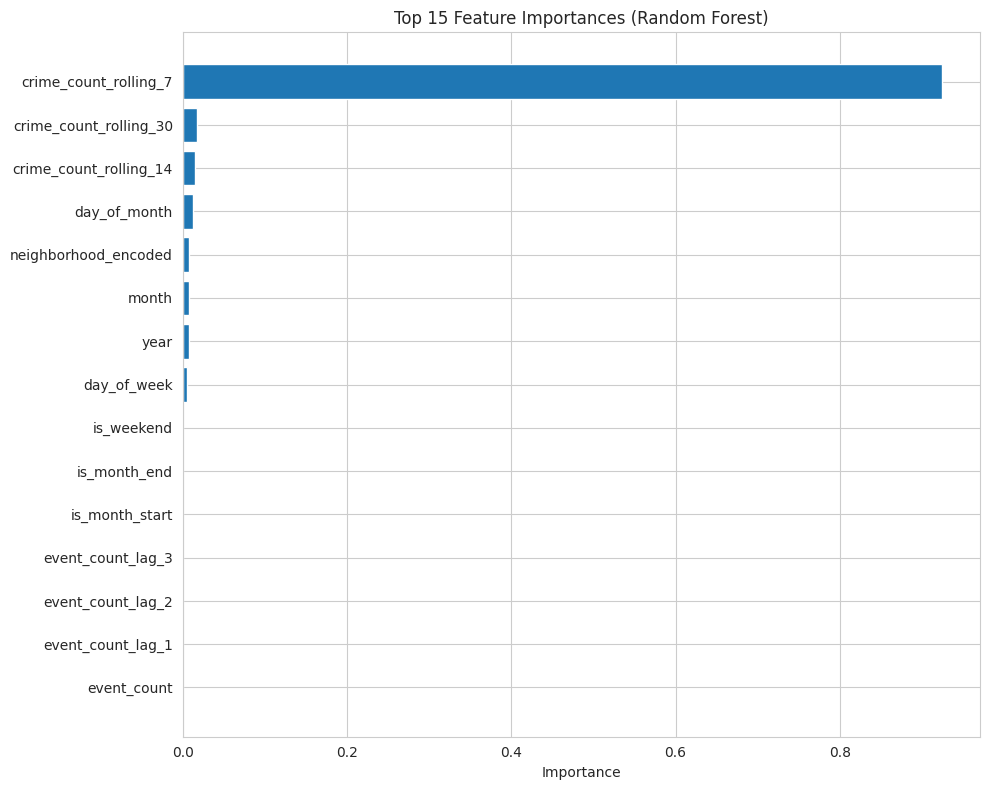

In [25]:
# Feature importance for Random Forest
if 'Random Forest' in models:
    rf_model = models['Random Forest']
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    print("\n=== Feature Importance (Random Forest) ===")
    print(feature_importance.head(15))
    
    # Plot top features
    plt.figure(figsize=(10, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'].values)
    plt.yticks(range(len(top_features)), top_features['feature'].values)
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances (Random Forest)')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('../UrbanPulse-report/content/figures/crime_prediction_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()


### 4.2 Classification: Predicting High Crime Days


In [16]:
# Create binary classification task: high crime day (above median) vs low crime day
crime_median = model_df[target_col].median()
print(f"Median crime count: {crime_median}")

model_df_class = model_df.copy()
model_df_class['high_crime'] = (model_df_class[target_col] > crime_median).astype(int)

high_crime_pct = (model_df_class['high_crime'].sum() / len(model_df_class) * 100)
low_crime_pct = ((~model_df_class['high_crime'].astype(bool)).sum() / len(model_df_class) * 100)

print(f"\nHigh crime days: {model_df_class['high_crime'].sum():,} ({high_crime_pct:.1f}%)")
print(f"Low crime days: {(~model_df_class['high_crime'].astype(bool)).sum():,} ({low_crime_pct:.1f}%)")

# Prepare classification data
X_class = model_df_class[feature_cols]
y_class = model_df_class['high_crime']

# Use same train/test split
X_train_class = model_df_class[train_mask][feature_cols]
y_train_class = model_df_class[train_mask]['high_crime']
X_test_class = model_df_class[test_mask][feature_cols]
y_test_class = model_df_class[test_mask]['high_crime']

print(f"\nTraining set: {len(X_train_class):,} samples")
print(f"Test set: {len(X_test_class):,} samples")


Median crime count: 0.0

High crime days: 351,920 (24.3%)
Low crime days: 1,098,752 (75.7%)

Training set: 1,160,424 samples
Test set: 290,248 samples


In [17]:
# Train classification models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

class_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

class_results = {}

print("Training classification models...\n")
for name, model in class_models.items():
    print(f"Training {name}...")
    
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_class)
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train_class, y_train_class)
        y_pred = model.predict(X_test_class)
        y_pred_proba = model.predict_proba(X_test_class)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test_class, y_pred)
    precision = precision_score(y_test_class, y_pred)
    recall = recall_score(y_test_class, y_pred)
    f1 = f1_score(y_test_class, y_pred)
    roc_auc = roc_auc_score(y_test_class, y_pred_proba)
    
    class_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}\n")

# Display results
class_results_df = pd.DataFrame(class_results).T
print("\n=== Classification Model Comparison ===")
print(class_results_df)


Training classification models...

Training Logistic Regression...
  Accuracy: 0.9545, Precision: 0.8183, Recall: 0.9954, F1: 0.8982, ROC-AUC: 0.9968

Training Random Forest...
  Accuracy: 0.9807, Precision: 0.9309, Recall: 0.9766, F1: 0.9532, ROC-AUC: 0.9972

Training Gradient Boosting...
  Accuracy: 0.9811, Precision: 0.9254, Recall: 0.9857, F1: 0.9546, ROC-AUC: 0.9974


=== Classification Model Comparison ===
                     Accuracy Precision    Recall        F1   ROC-AUC  \
Logistic Regression  0.954525  0.818281  0.995436  0.898207  0.996777   
Random Forest        0.980685  0.930943  0.976615  0.953233  0.997181   
Gradient Boosting    0.981106   0.92538  0.985744  0.954609  0.997399   

                                                           predictions  
Logistic Regression  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
Random Forest        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  
Gradient Boosting    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...  

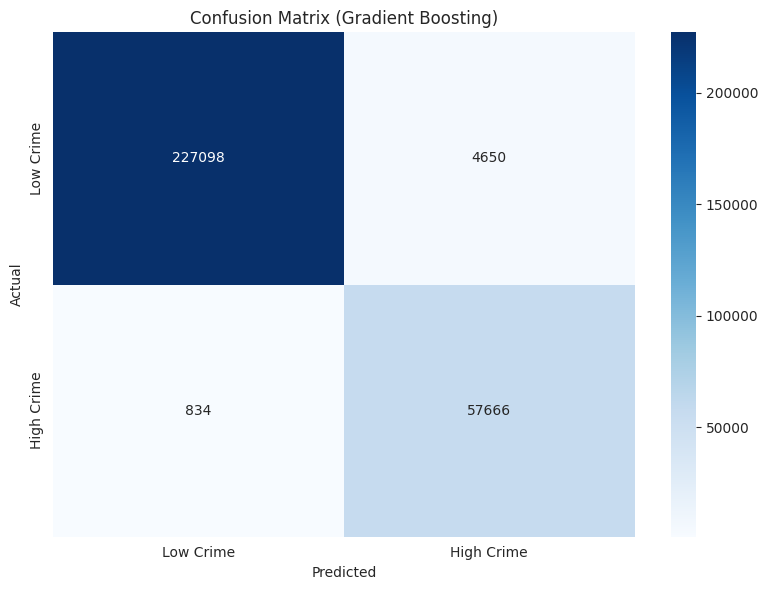


Best Classification Model: Gradient Boosting
Accuracy: 0.9811
F1 Score: 0.9546
ROC-AUC: 0.9974


In [26]:
# Confusion matrix for best classifier
best_class_name = class_results_df.sort_values('F1', ascending=False).index[0]
best_class_pred = class_results[best_class_name]['predictions']

from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test_class, best_class_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Low Crime', 'High Crime'],
            yticklabels=['Low Crime', 'High Crime'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title(f'Confusion Matrix ({best_class_name})')
plt.tight_layout()
plt.savefig('../UrbanPulse-report/content/figures/crime_classification_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nBest Classification Model: {best_class_name}")
print(f"Accuracy: {class_results[best_class_name]['Accuracy']:.4f}")
print(f"F1 Score: {class_results[best_class_name]['F1']:.4f}")
print(f"ROC-AUC: {class_results[best_class_name]['ROC-AUC']:.4f}")


## 5. Analysis: Event Impact on Crime


=== Event Days vs Non-Event Days ===
Event days: 61,175
Non-event days: 1,389,497

Average crime on event days: 0.00
Average crime on non-event days: 1.94
Difference: -1.94

T-test: t-statistic=-93.5851, p-value=0.0000e+00


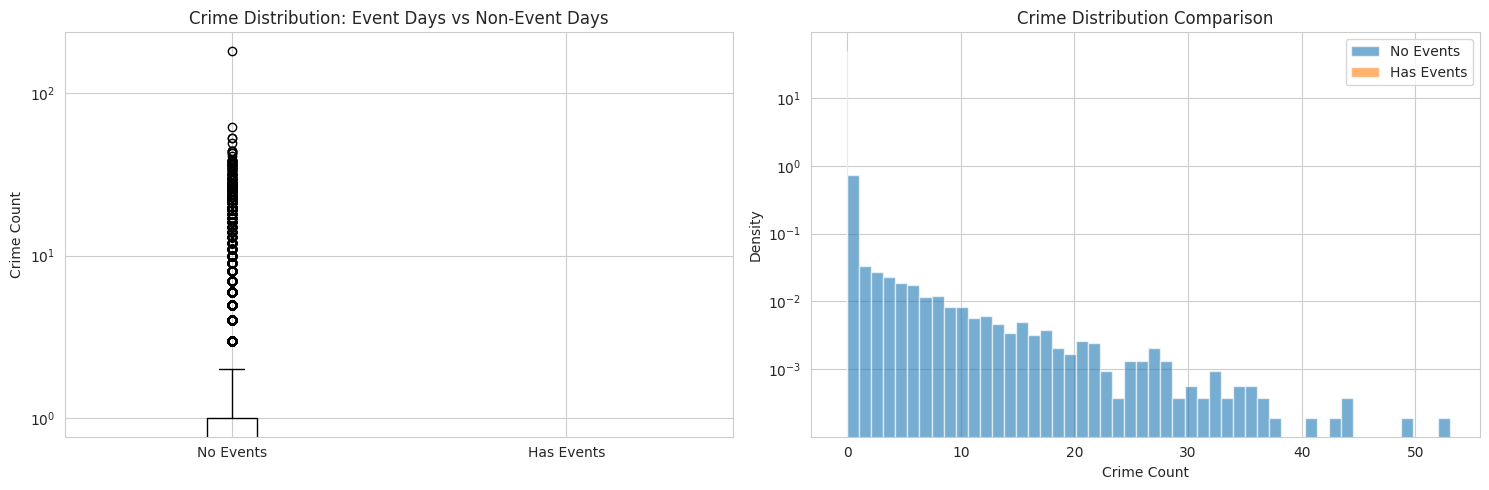

In [27]:
# Analyze crime patterns on event days vs non-event days
event_days = model_df[model_df['event_count'] > 0]
non_event_days = model_df[model_df['event_count'] == 0]

print("=== Event Days vs Non-Event Days ===")
print(f"Event days: {len(event_days):,}")
print(f"Non-event days: {len(non_event_days):,}")
print(f"\nAverage crime on event days: {event_days[target_col].mean():.2f}")
print(f"Average crime on non-event days: {non_event_days[target_col].mean():.2f}")
print(f"Difference: {event_days[target_col].mean() - non_event_days[target_col].mean():.2f}")

# Statistical test
from scipy import stats
t_stat, p_value = stats.ttest_ind(event_days[target_col], non_event_days[target_col])
print(f"\nT-test: t-statistic={t_stat:.4f}, p-value={p_value:.4e}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot
data_to_plot = [non_event_days[target_col].sample(min(10000, len(non_event_days)), random_state=42),
                event_days[target_col].sample(min(10000, len(event_days)), random_state=42)]
axes[0].boxplot(data_to_plot, labels=['No Events', 'Has Events'])
axes[0].set_ylabel('Crime Count')
axes[0].set_title('Crime Distribution: Event Days vs Non-Event Days')
axes[0].set_yscale('log')

# Histogram comparison
axes[1].hist(non_event_days[target_col].sample(min(5000, len(non_event_days)), random_state=42), 
             bins=50, alpha=0.6, label='No Events', density=True)
axes[1].hist(event_days[target_col].sample(min(5000, len(event_days)), random_state=42), 
             bins=50, alpha=0.6, label='Has Events', density=True)
axes[1].set_xlabel('Crime Count')
axes[1].set_ylabel('Density')
axes[1].set_title('Crime Distribution Comparison')
axes[1].legend()
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('../UrbanPulse-report/content/figures/event_crime_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


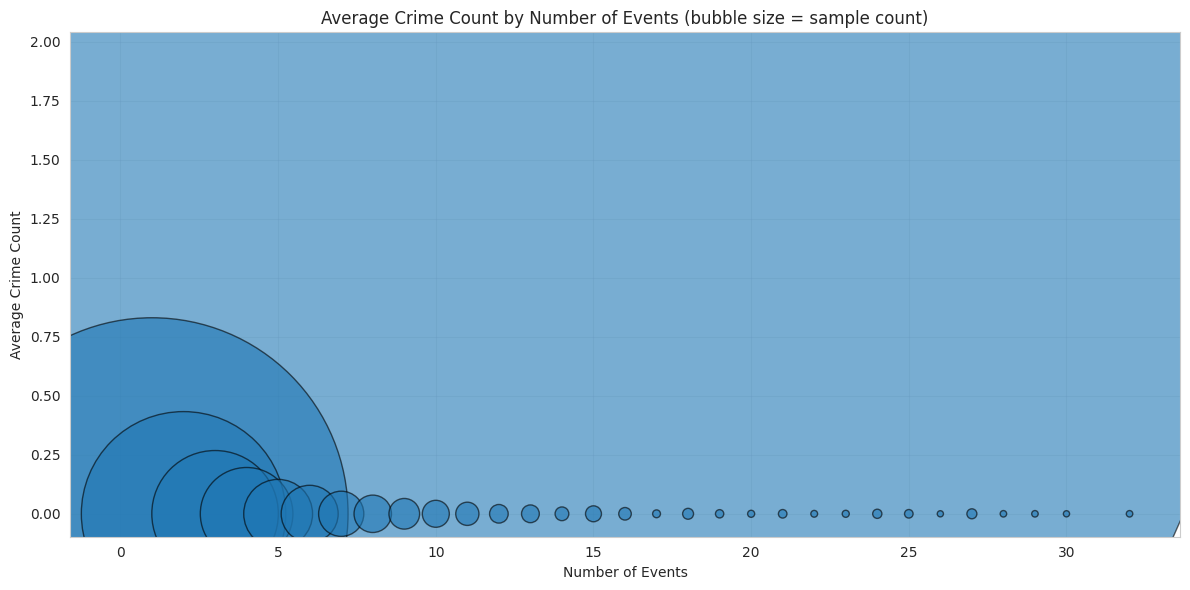


=== Crime by Event Count ===
    event_count      mean       std    count
0             0  1.942355  5.133442  1389497
1             1  0.000000  0.000000    39852
2             2  0.000000  0.000000    10830
3             3  0.000000  0.000000     4150
4             4  0.000000  0.000000     2223
5             5  0.000000  0.000000     1228
6             6  0.000000  0.000000      842
7             7  0.000000  0.000000      530
8             8  0.000000  0.000000      363
9             9  0.000000  0.000000      244
10           10  0.000000  0.000000      189
11           11  0.000000  0.000000      140
12           12  0.000000  0.000000       90
13           13  0.000000  0.000000       82
14           14  0.000000  0.000000       49
15           15  0.000000  0.000000       66
16           16  0.000000  0.000000       41
17           17  0.000000  0.000000       16
18           18  0.000000  0.000000       31
19           19  0.000000  0.000000       18


In [28]:
# Analyze by number of events
event_analysis = model_df.groupby('event_count')[target_col].agg(['mean', 'std', 'count']).reset_index()
event_analysis = event_analysis[event_analysis['count'] >= 10]  # Only include event counts with at least 10 samples

plt.figure(figsize=(12, 6))
plt.scatter(event_analysis['event_count'], event_analysis['mean'], 
           s=event_analysis['count']*2, alpha=0.6, edgecolors='black')
plt.xlabel('Number of Events')
plt.ylabel('Average Crime Count')
plt.title('Average Crime Count by Number of Events (bubble size = sample count)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../UrbanPulse-report/content/figures/crime_by_event_count.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Crime by Event Count ===")
print(event_analysis.head(20))


## 6. Summary and Conclusions


In [22]:
print("=== SUMMARY ===")
print(f"\n1. Dataset Statistics:")
print(f"   - Total crime records: {len(crime_df):,}")
print(f"   - Total event records: {len(events_df):,}")

# Handle date formatting - min_date and max_date might already be date objects
try:
    if hasattr(min_date, 'date'):
        min_date_str = min_date.date()
    else:
        min_date_str = min_date
    if hasattr(max_date, 'date'):
        max_date_str = max_date.date()
    else:
        max_date_str = max_date
    print(f"   - Date range: {min_date_str} to {max_date_str}")
except NameError:
    print(f"   - Date range: Not available")

try:
    print(f"   - Neighborhoods analyzed: {len(all_neighborhoods)}")
except NameError:
    print(f"   - Neighborhoods analyzed: Not available")

# Regression results
try:
    print(f"\n2. Best Regression Model: {best_model_name}")
    print(f"   - RMSE: {results[best_model_name]['RMSE']:.2f}")
    print(f"   - MAE: {results[best_model_name]['MAE']:.2f}")
    print(f"   - R²: {results[best_model_name]['R2']:.4f}")
except NameError:
    print(f"\n2. Regression Model: Not available (models not trained)")

# Classification results
try:
    print(f"\n3. Best Classification Model: {best_class_name}")
    print(f"   - Accuracy: {class_results[best_class_name]['Accuracy']:.4f}")
    print(f"   - F1 Score: {class_results[best_class_name]['F1']:.4f}")
    print(f"   - ROC-AUC: {class_results[best_class_name]['ROC-AUC']:.4f}")
except NameError:
    print(f"\n3. Classification Model: Not available (models not trained)")

# Key findings
try:
    print(f"\n4. Key Findings:")
    event_crime_mean = event_days[target_col].mean()
    non_event_crime_mean = non_event_days[target_col].mean()
    print(f"   - Average crime on event days: {event_crime_mean:.2f}")
    print(f"   - Average crime on non-event days: {non_event_crime_mean:.2f}")
    print(f"   - Statistical significance (p-value): {p_value:.4e}")
    
    if p_value < 0.05:
        if event_crime_mean > non_event_crime_mean:
            print(f"   - Events are associated with HIGHER crime rates")
        else:
            print(f"   - Events are associated with LOWER crime rates")
    else:
        print(f"   - No statistically significant difference in crime rates between event and non-event days")
except NameError:
    print(f"\n4. Key Findings: Not available (analysis not completed)")


=== SUMMARY ===

1. Dataset Statistics:
   - Total crime records: 2,698,897
   - Total event records: 116,853
   - Date range: 2012-01-07 to 2025-12-31
   - Neighborhoods analyzed: 284

2. Best Regression Model: Gradient Boosting
   - RMSE: 1.33
   - MAE: 0.45
   - R²: 0.9122

3. Best Classification Model: Gradient Boosting
   - Accuracy: 0.9811
   - F1 Score: 0.9546
   - ROC-AUC: 0.9974

4. Key Findings:
   - Average crime on event days: 0.00
   - Average crime on non-event days: 1.94
   - Statistical significance (p-value): 0.0000e+00
   - Events are associated with LOWER crime rates
